# Random Forest Model — Employee Attrition Prediction
 
**Project:** XGBoost vs Random Forest — Comparative Analysis  
**Dataset:** IBM HR Analytics Employee Attrition (Kaggle - preprocessed by Notebook 01)  

---

### Notebook outline
1. Imports & configuration
2. Load preprocessed data from Notebook 01
3. Data verification
4. Baseline Random Forest
5. Hyperparameter tuning (RandomizedSearchCV)
6. Tuned model evaluation
7. Confusion matrix & ROC / PR curves
8. Feature importance analysis
9. Threshold optimisation
10. Save model & results summary


## 1. Imports & Configuration

In [22]:
# ── Standard library ────────────────────────────────────────────────────────
import warnings
import os

warnings.filterwarnings('ignore')

# ── Data handling ────────────────────────────────────────────────────────────
import numpy as np
import pandas as pd

# ── Visualisation ────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# ── Scikit-learn ─────────────────────────────────────────────────────────────
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import (
    RandomizedSearchCV,
    StratifiedKFold,
    cross_val_score,
)
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    precision_recall_curve,
    average_precision_score,
)
from sklearn.inspection import permutation_importance

# ── Scipy ─────────────────────────────────────────────────────────────────────
from scipy.stats import randint

# ImbPipeline wraps SMOTE inside CV folds to prevent data leakage
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE

import joblib

# ── Global plot style ─────────────────────────────────────────────────────────
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
RANDOM_STATE = 42
FIGURES_DIR  = '../figures'
MODELS_DIR   = '../models'
os.makedirs(FIGURES_DIR, exist_ok=True)
os.makedirs(MODELS_DIR,  exist_ok=True)
print('All libraries loaded successfully')

All libraries loaded successfully


## 2. Load Preprocessed Data from Notebook 01

We load **two sets** of training data saved by Notebook 01:
- `X_train.csv` / `y_train.csv` — SMOTE-balanced, used to **train** the final model
- `X_train_orig.csv` / `y_train_orig.csv` — original unbalanced, used for **cross-validation** to avoid leakage

> **Why two sets?** SMOTE creates synthetic minority samples. If CV folds are made
> from SMOTE data, synthetic copies of the same original point appear in both the
> train and validation fold — causing unrealistically inflated scores (e.g. 0.97
> ROC-AUC on CV but only 0.74 on test). CV must always run on original data.

In [23]:
PROCESSED_DIR = '../data/processed'

# SMOTE-balanced splits — for model training
X_train = pd.read_csv(os.path.join(PROCESSED_DIR, 'X_train.csv'))
y_train = pd.read_csv(os.path.join(PROCESSED_DIR, 'y_train.csv')).squeeze()

# Original unbalanced splits — for cross-validation only
X_train_orig = pd.read_csv(os.path.join(PROCESSED_DIR, 'X_train_orig.csv'))
y_train_orig = pd.read_csv(os.path.join(PROCESSED_DIR, 'y_train_orig.csv')).squeeze()

# Test set — never touched during training
X_test = pd.read_csv(os.path.join(PROCESSED_DIR, 'X_test.csv'))
y_test = pd.read_csv(os.path.join(PROCESSED_DIR, 'y_test.csv')).squeeze()

print('Data loaded successfully from data/processed/')
print(f'X_train (SMOTE)    : {X_train.shape}')
print(f'X_train (original) : {X_train_orig.shape}')
print(f'X_test             : {X_test.shape}')
print(f'y_train (SMOTE)    : {y_train.shape}')
print(f'y_train (original) : {y_train_orig.shape}')
print(f'y_test             : {y_test.shape}')

Data loaded successfully from data/processed/
X_train (SMOTE)    : (1972, 44)
X_train (original) : (1176, 44)
X_test             : (294, 44)
y_train (SMOTE)    : (1972,)
y_train (original) : (1176,)
y_test             : (294,)


## 3. Data Verification

In [24]:
print('SMOTE training class distribution:')
print(y_train.value_counts())
print(f'Attrition rate (SMOTE train)   : {y_train.mean()*100:.1f}%')

print('\nOriginal training class distribution:')
print(y_train_orig.value_counts())
print(f'Attrition rate (original train): {y_train_orig.mean()*100:.1f}%')

print(f'\nAttrition rate in test set     : {y_test.mean()*100:.1f}%')
print(f'\nFeature columns: {X_train.shape[1]}')
print(f'\nSample features: {list(X_train.columns[:6])} ...')

SMOTE training class distribution:
Attrition
0    986
1    986
Name: count, dtype: int64
Attrition rate (SMOTE train)   : 50.0%

Original training class distribution:
Attrition
0    986
1    190
Name: count, dtype: int64
Attrition rate (original train): 16.2%

Attrition rate in test set     : 16.0%

Feature columns: 44

Sample features: ['Age', 'DailyRate', 'DistanceFromHome', 'Education', 'EnvironmentSatisfaction', 'Gender'] ...


## 4. Baseline Random Forest

Training with default hyperparameters on SMOTE data to establish a baseline.  
Cross-validation runs on the **original unbalanced** data via `ImbPipeline`
to give honest CV scores that won't be inflated.

In [25]:
# ── Baseline model with default hyperparameters ───────────────────────────────
rf_baseline = RandomForestClassifier(
    n_estimators=100,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

rf_baseline.fit(X_train, y_train)

y_pred_base  = rf_baseline.predict(X_test)
y_proba_base = rf_baseline.predict_proba(X_test)[:, 1]

print('=== Baseline Random Forest ===')
print(classification_report(y_test, y_pred_base, target_names=['No Attrition', 'Attrition']))
print(f'ROC-AUC : {roc_auc_score(y_test, y_proba_base):.4f}')

=== Baseline Random Forest ===
              precision    recall  f1-score   support

No Attrition       0.88      0.94      0.91       247
   Attrition       0.48      0.30      0.37        47

    accuracy                           0.84       294
   macro avg       0.68      0.62      0.64       294
weighted avg       0.81      0.84      0.82       294

ROC-AUC : 0.7398


In [26]:
# ── CV uses ImbPipeline on ORIGINAL data — prevents SMOTE leakage into CV folds
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

baseline_pipeline = ImbPipeline([
    ('smote', SMOTE(random_state=RANDOM_STATE)),
    ('rf',    RandomForestClassifier(n_estimators=100,
                                     random_state=RANDOM_STATE,
                                     n_jobs=-1))
]) 

cv_roc  = cross_val_score(baseline_pipeline, X_train_orig, y_train_orig, cv=cv, scoring='roc_auc',  n_jobs=-1)
cv_f1   = cross_val_score(baseline_pipeline, X_train_orig, y_train_orig, cv=cv, scoring='f1',       n_jobs=-1)
cv_acc  = cross_val_score(baseline_pipeline, X_train_orig, y_train_orig, cv=cv, scoring='accuracy', n_jobs=-1)

print('=== 5-Fold CV — Baseline RF (SMOTE inside folds, original data) ===')
print(f'CV ROC-AUC : {cv_roc.mean():.4f} +/- {cv_roc.std():.4f}')
print(f'CV F1      : {cv_f1.mean():.4f}  +/- {cv_f1.std():.4f}')
print(f'CV Accuracy: {cv_acc.mean():.4f} +/- {cv_acc.std():.4f}')

=== 5-Fold CV — Baseline RF (SMOTE inside folds, original data) ===
CV ROC-AUC : 0.7669 +/- 0.0421
CV F1      : 0.4332  +/- 0.0987
CV Accuracy: 0.8571 +/- 0.0219


## 5. Hyperparameter Tuning — RandomizedSearchCV

We search over a wide parameter space using 80 random combinations with 5-fold
stratified CV, optimising for **ROC-AUC** since it handles class imbalance better
than accuracy.  
Tuning also uses `ImbPipeline` so SMOTE stays inside each CV fold.

In [27]:
# ── param keys prefixed with 'rf__' because estimator is now a pipeline ────────
param_dist = {
    'rf__n_estimators'      : randint(100, 600),
    'rf__max_depth'         : [None, 5, 10, 15, 20, 25],
    'rf__min_samples_split' : randint(2, 20),
    'rf__min_samples_leaf'  : randint(1, 10),
    'rf__max_features'      : ['sqrt', 'log2', 0.5, 0.7],
    'rf__class_weight'      : ['balanced', 'balanced_subsample', None],
    'rf__bootstrap'         : [True, False],
    'rf__criterion'         : ['gini', 'entropy'],
}

tune_pipeline = ImbPipeline([
    ('smote', SMOTE(random_state=RANDOM_STATE)),
    ('rf',    RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1))
])

rf_search = RandomizedSearchCV(
    estimator  = tune_pipeline,
    param_distributions = param_dist,
    n_iter     = 80,           # number of random combinations to try
    cv         = cv,
    scoring    = 'roc_auc',    # optimise for AUC (handles imbalance better)
    refit      = True,
    verbose    = 1,
    random_state = RANDOM_STATE,
    n_jobs     = -1
)

# fit on ORIGINAL data — SMOTE applied inside each CV fold
rf_search.fit(X_train_orig, y_train_orig)


print('\n Tuning complete!')
print(f'Best CV ROC-AUC : {rf_search.best_score_:.4f}')
print('Best Parameters :')
for k, v in rf_search.best_params_.items():
    # Strip 'rf__' prefix for clean display
    print(f'  {k.replace("rf__", "")}: {v}')

Fitting 5 folds for each of 80 candidates, totalling 400 fits

 Tuning complete!
Best CV ROC-AUC : 0.7742
Best Parameters :
  bootstrap: True
  class_weight: None
  criterion: gini
  max_depth: 15
  max_features: sqrt
  min_samples_leaf: 7
  min_samples_split: 3
  n_estimators: 269


## 6. Tuned Model Evaluation

In [28]:
# Best estimator is the full pipeline; extract RF step for feature importance
best_pipeline = rf_search.best_estimator_
rf_tuned      = best_pipeline.named_steps['rf']  # extract RF step

y_pred_tuned  = best_pipeline.predict(X_test)
y_proba_tuned = best_pipeline.predict_proba(X_test)[:, 1]

# ── Metrics ──────────────────────────────────────────────────────────────────
metrics = {
    'Accuracy' : accuracy_score(y_test, y_pred_tuned),
    'Precision': precision_score(y_test, y_pred_tuned, zero_division=0),
    'Recall'   : recall_score(y_test, y_pred_tuned, zero_division=0),
    'F1-Score' : f1_score(y_test, y_pred_tuned, zero_division=0),
    'ROC-AUC'  : roc_auc_score(y_test, y_proba_tuned),
    'PR-AUC'   : average_precision_score(y_test, y_proba_tuned),
}

print('=== Tuned Random Forest — Test Set Metrics ===')
for k, v in metrics.items():
    print(f'  {k:<12}: {v:.4f}')

print('\n--- Classification Report ---')
print(classification_report(y_test, y_pred_tuned, target_names=['No Attrition', 'Attrition']))

=== Tuned Random Forest — Test Set Metrics ===
  Accuracy    : 0.8061
  Precision   : 0.3750
  Recall      : 0.3191
  F1-Score    : 0.3448
  ROC-AUC     : 0.7338
  PR-AUC      : 0.3611

--- Classification Report ---
              precision    recall  f1-score   support

No Attrition       0.87      0.90      0.89       247
   Attrition       0.38      0.32      0.34        47

    accuracy                           0.81       294
   macro avg       0.62      0.61      0.62       294
weighted avg       0.79      0.81      0.80       294



In [29]:
# Baseline vs tuned comparison table
baseline_metrics = {
    'Accuracy'  : accuracy_score(y_test, y_pred_base),
    'Precision' : precision_score(y_test, y_pred_base, zero_division=0),
    'Recall'    : recall_score(y_test, y_pred_base, zero_division=0),
    'F1-Score'  : f1_score(y_test, y_pred_base, zero_division=0),
    'ROC-AUC'   : roc_auc_score(y_test, y_proba_base),
    'PR-AUC'    : average_precision_score(y_test, y_proba_base),
}

comparison_df = pd.DataFrame({
    'Baseline RF' : baseline_metrics,
    'Tuned RF'    : metrics
}).round(4)

print('=== Baseline vs Tuned Comparison ===')
print(comparison_df)

=== Baseline vs Tuned Comparison ===
           Baseline RF  Tuned RF
Accuracy        0.8367    0.8061
Precision       0.4828    0.3750
Recall          0.2979    0.3191
F1-Score        0.3684    0.3448
ROC-AUC         0.7398    0.7338
PR-AUC          0.3593    0.3611


## 7. Confusion Matrix & ROC / PR Curves

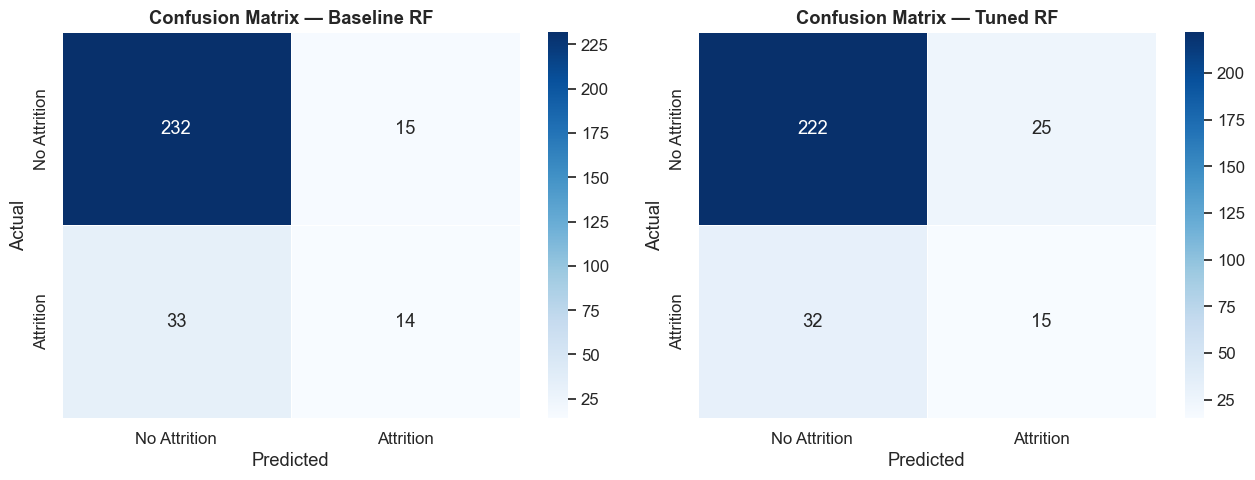

In [30]:
# Confusion matrices — baseline vs tuned
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, y_pred, title in zip(
    axes,
    [y_pred_base, y_pred_tuned],
    ['Baseline RF', 'Tuned RF']
):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['No Attrition', 'Attrition'],
                yticklabels=['No Attrition', 'Attrition'],
                linewidths=0.5)
    ax.set_title(f'Confusion Matrix — {title}', fontweight='bold')
    ax.set_ylabel('Actual')
    ax.set_xlabel('Predicted')

plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/rf_01_confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

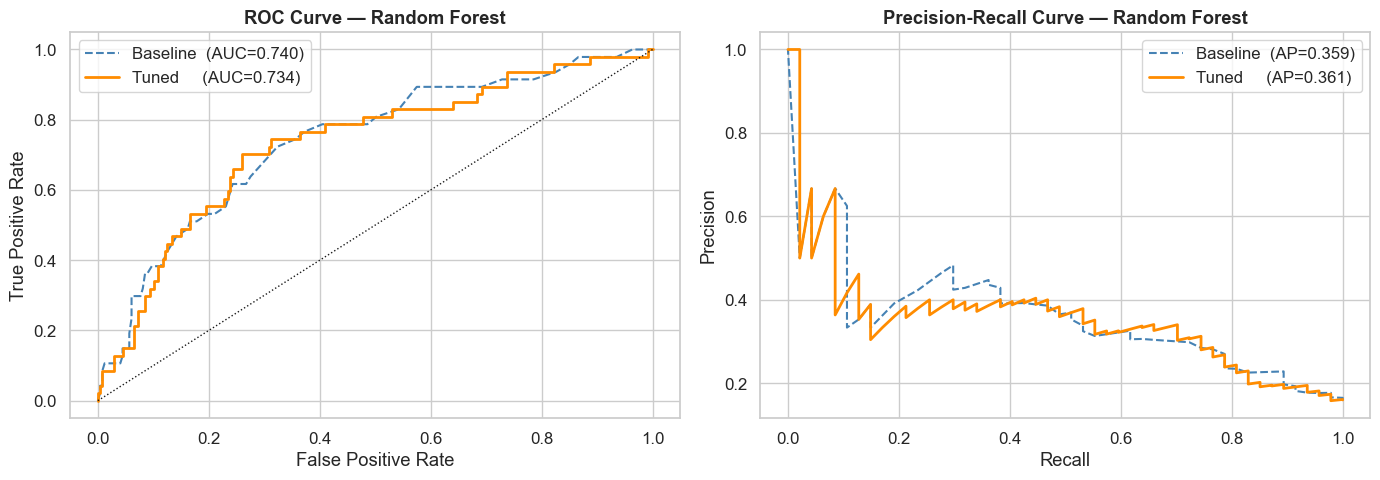

In [31]:
# ── ROC & Precision-Recall curves ─────────────────────────────────────────────
fpr_base,  tpr_base,  _ = roc_curve(y_test, y_proba_base)
fpr_tuned, tpr_tuned, _ = roc_curve(y_test, y_proba_tuned)

prec_base,  rec_base,  _ = precision_recall_curve(y_test, y_proba_base)
prec_tuned, rec_tuned, _ = precision_recall_curve(y_test, y_proba_tuned)

auc_base  = roc_auc_score(y_test, y_proba_base)
auc_tuned = roc_auc_score(y_test, y_proba_tuned)
ap_base   = average_precision_score(y_test, y_proba_base)
ap_tuned  = average_precision_score(y_test, y_proba_tuned)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ROC curve
axes[0].plot(fpr_base,  tpr_base,  label=f'Baseline  (AUC={auc_base:.3f})',  lw=1.5, linestyle='--', color='steelblue')
axes[0].plot(fpr_tuned, tpr_tuned, label=f'Tuned     (AUC={auc_tuned:.3f})', lw=2.0, color='darkorange')
axes[0].plot([0,1],[0,1], 'k:', lw=1)
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curve — Random Forest', fontweight='bold')
axes[0].legend()

# PR curve
axes[1].plot(rec_base,  prec_base,  label=f'Baseline  (AP={ap_base:.3f})',  lw=1.5, linestyle='--', color='steelblue')
axes[1].plot(rec_tuned, prec_tuned, label=f'Tuned     (AP={ap_tuned:.3f})', lw=2.0, color='darkorange')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall Curve — Random Forest', fontweight='bold')
axes[1].legend()

plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/rf_02_roc_pr_curves.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Feature Importance Analysis

Two views of feature importance:
- **Gini importance** — built-in RF impurity-based scores
- **Top 20 bar chart** — ranked visual for report

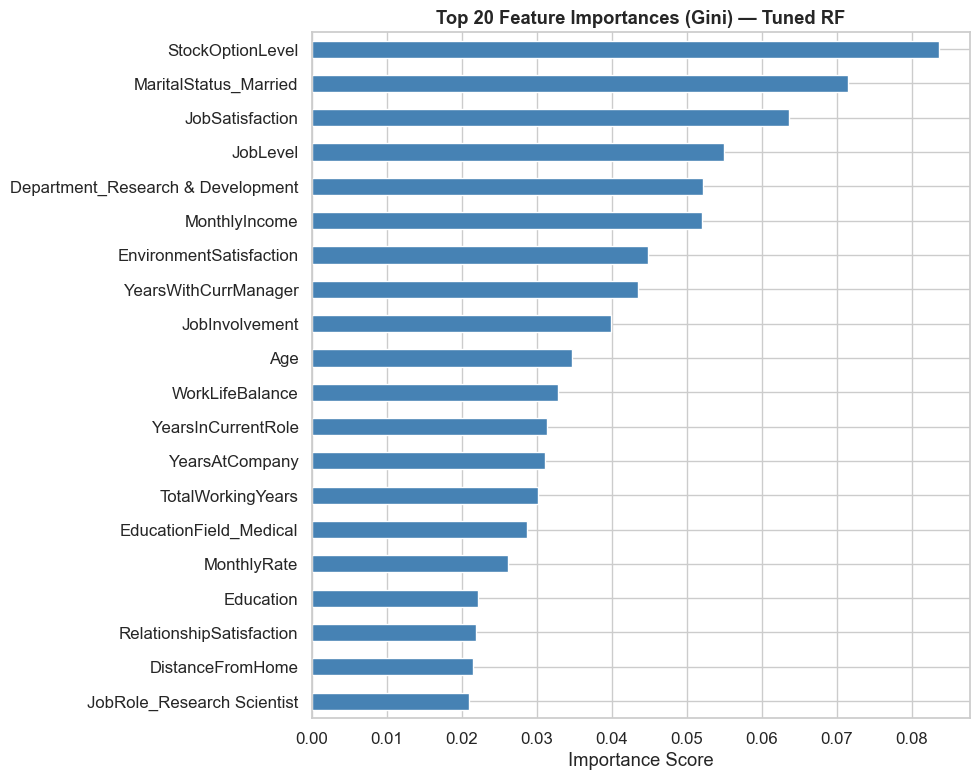

Top 10 features (Gini importance):
StockOptionLevel                     0.083634
MaritalStatus_Married                0.071523
JobSatisfaction                      0.063616
JobLevel                             0.054903
Department_Research & Development    0.052166
MonthlyIncome                        0.052057
EnvironmentSatisfaction              0.044782
YearsWithCurrManager                 0.043484
JobInvolvement                       0.039907
Age                                  0.034731


In [32]:
# Gini (impurity-based) feature importance from the RF step of the pipeline
feat_imp = pd.Series(
    rf_tuned.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

# Top 20 bar chart
fig, ax = plt.subplots(figsize=(10, 8))
feat_imp.head(20).sort_values().plot(
    kind='barh', ax=ax, color='steelblue', edgecolor='white'
)
ax.set_title('Top 20 Feature Importances (Gini) — Tuned RF', fontweight='bold')
ax.set_xlabel('Importance Score')
plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/rf_03_feature_importance_gini.png', dpi=150, bbox_inches='tight')
plt.show()

print('Top 10 features (Gini importance):')
print(feat_imp.head(10).to_string())

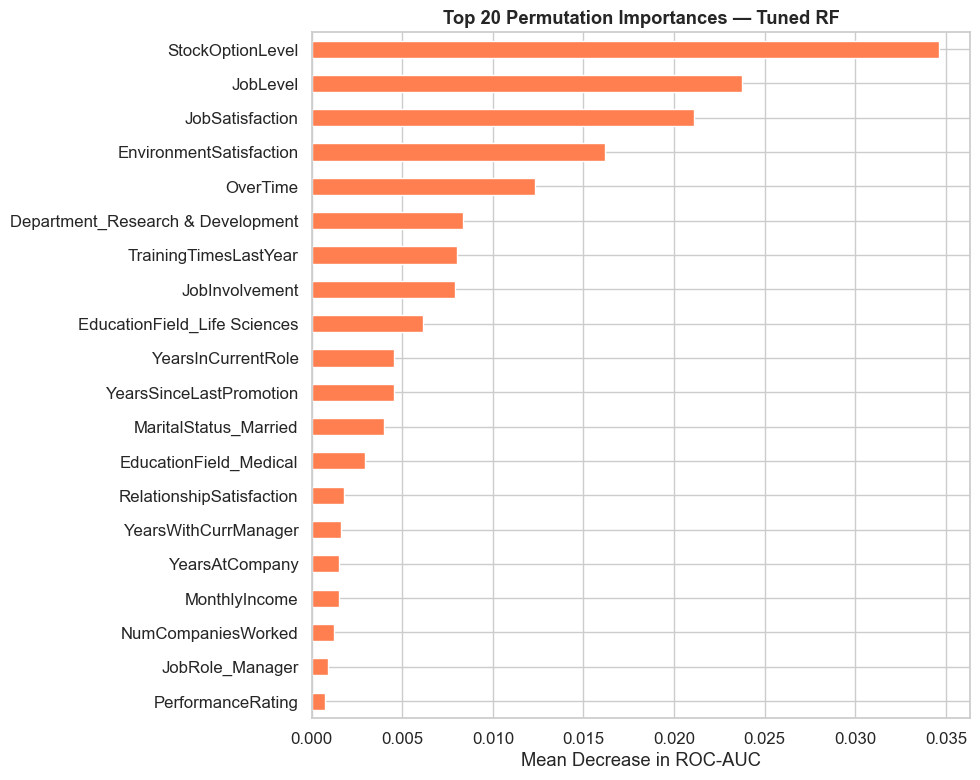

Saved: rf_04_feature_importance_permutation.png

Top 10 features (Permutation importance):
StockOptionLevel                     0.034623
JobLevel                             0.023769
JobSatisfaction                      0.021076
EnvironmentSatisfaction              0.016171
OverTime                             0.012341
Department_Research & Development    0.008373
TrainingTimesLastYear                0.007994
JobInvolvement                       0.007919
EducationField_Life Sciences         0.006122
YearsInCurrentRole                   0.004565


In [33]:
# ── Permutation importance on test set (model-agnostic, more reliable) ───────────────────
perm_imp = permutation_importance(
    rf_tuned, X_test, y_test,
    n_repeats=15,
    random_state=RANDOM_STATE,
    scoring='roc_auc',
    n_jobs=-1
)

perm_series = pd.Series(
    perm_imp.importances_mean,
    index=X_train.columns
).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 8))
perm_series.head(20).sort_values().plot(
    kind='barh', ax=ax, color='coral', edgecolor='white'
)
ax.set_title('Top 20 Permutation Importances — Tuned RF', fontweight='bold')
ax.set_xlabel('Mean Decrease in ROC-AUC')
plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/rf_04_feature_importance_permutation.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: rf_04_feature_importance_permutation.png')

print('\nTop 10 features (Permutation importance):')
print(perm_series.head(10).to_string())

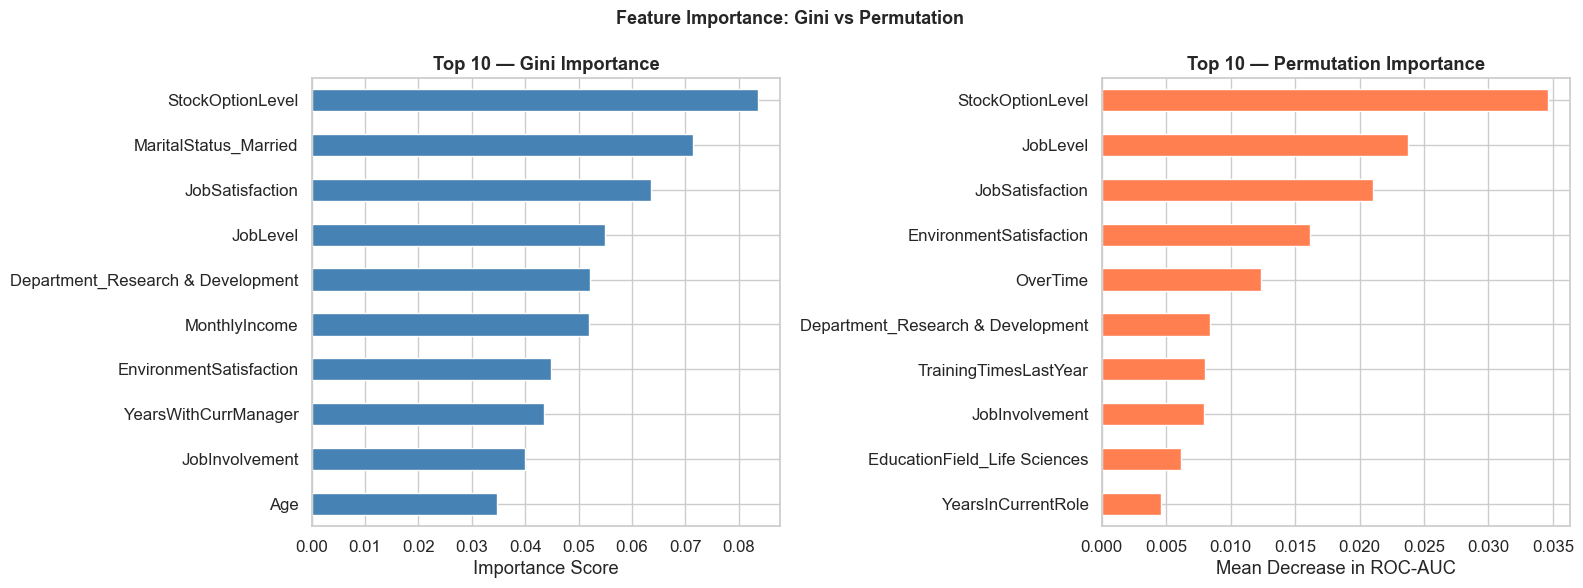

Saved: rf_05_importance_comparison.png


In [34]:
# Side-by-side comparison: Gini vs Permutation top 10
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

feat_imp.head(10).sort_values().plot(
    kind='barh', ax=axes[0], color='steelblue', edgecolor='white'
)
axes[0].set_title('Top 10 — Gini Importance', fontweight='bold')
axes[0].set_xlabel('Importance Score')

perm_series.head(10).sort_values().plot(
    kind='barh', ax=axes[1], color='coral', edgecolor='white'
)
axes[1].set_title('Top 10 — Permutation Importance', fontweight='bold')
axes[1].set_xlabel('Mean Decrease in ROC-AUC')

plt.suptitle('Feature Importance: Gini vs Permutation', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/rf_05_importance_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: rf_05_importance_comparison.png')

## 9. Threshold Optimisation

The default decision threshold (0.5) is often suboptimal for imbalanced data. We sweep thresholds and find the one that maximises F1.

Default threshold (0.50) F1  : 0.3448
Optimal threshold (0.33) F1: 0.4583


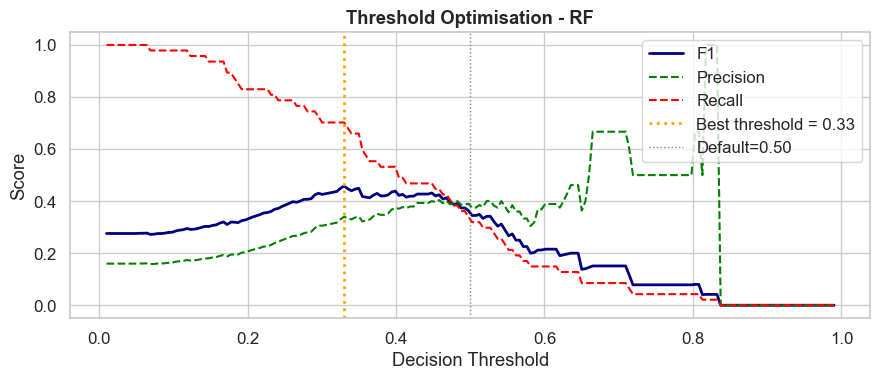

Saved: rf_06_threshold_optimisation.png


In [35]:
# ── Sweep thresholds and find optimal F1 ──────────────────────────────────────
thresholds = np.linspace(0.01, 0.99, 200)
f1_scores, prec_scores, rec_scores = [], [], []

for thr in thresholds:
    preds = (y_proba_tuned >= thr).astype(int)
    f1_scores.append(f1_score(y_test, preds, zero_division=0))
    prec_scores.append(precision_score(y_test, preds, zero_division=0))
    rec_scores.append(recall_score(y_test, preds, zero_division=0))

best_ix  = np.argmax(f1_scores)
best_thr = thresholds[best_ix]
best_f1  = f1_scores[best_ix]

print(f'Default threshold (0.50) F1  : {f1_score(y_test, y_pred_tuned, zero_division=0):.4f}')
print(f'Optimal threshold ({best_thr:.2f}) F1: {best_f1:.4f}')

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(thresholds, f1_scores,   label='F1',       color='navy',   lw=2)
ax.plot(thresholds, prec_scores, label='Precision', color='green',  lw=1.5, linestyle='--')
ax.plot(thresholds, rec_scores,  label='Recall',    color='red',    lw=1.5, linestyle='--')
ax.axvline(best_thr, color='orange', lw=2, linestyle=':', label=f'Best threshold = {best_thr:.2f}')
ax.axvline(0.5,      color='grey',   lw=1, linestyle=':', label='Default=0.50')
ax.set_xlabel('Decision Threshold')
ax.set_ylabel('Score')
ax.set_title('Threshold Optimisation - RF', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/rf_06_threshold_optimisation.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: rf_06_threshold_optimisation.png')

In [36]:
# Evaluate with optimal threshold
y_pred_optimal = (y_proba_tuned >= best_thr).astype(int)

print(f'=== Metrics at Optimal Threshold ({best_thr:.2f}) ===')
print(classification_report(y_test, y_pred_optimal,
      target_names=['No Attrition', 'Attrition']))

# store for saving below
metrics_optimal = {
    'Accuracy'  : accuracy_score(y_test, y_pred_optimal),
    'Precision' : precision_score(y_test, y_pred_optimal, zero_division=0),
    'Recall'    : recall_score(y_test, y_pred_optimal, zero_division=0),
    'F1-Score'  : f1_score(y_test, y_pred_optimal, zero_division=0),
    'ROC-AUC'   : roc_auc_score(y_test, y_proba_tuned),
    'PR-AUC'    : average_precision_score(y_test, y_proba_tuned),
    'Threshold' : best_thr,
}

=== Metrics at Optimal Threshold (0.33) ===
              precision    recall  f1-score   support

No Attrition       0.93      0.74      0.82       247
   Attrition       0.34      0.70      0.46        47

    accuracy                           0.73       294
   macro avg       0.63      0.72      0.64       294
weighted avg       0.83      0.73      0.77       294



## 10. Save Model & Results Summary

In [37]:
# Save the full tuned pipeline (includes SMOTE step)
model_path = f'{MODELS_DIR}/random_forest_tuned.joblib'
joblib.dump(best_pipeline, model_path)
print(f'Pipeline saved to         : {model_path}')

# Save metrics at default threshold
metrics_df = pd.DataFrame([metrics], index=['Random Forest'])
metrics_df.to_csv(f'{MODELS_DIR}/rf_metrics.csv')
print(f'Metrics saved to {MODELS_DIR}/rf_metrics.csv')

# Save metrics at optimal threshold
metrics_opt_df = pd.DataFrame([metrics_optimal], index=['Random Forest (optimal thr)'])
metrics_opt_df.to_csv(f'{MODELS_DIR}/rf_metrics_optimal.csv')
print(f'Optimal metrics saved to  : {MODELS_DIR}/rf_metrics_optimal.csv')

# Save feature importances for comparison notebook
feat_imp.to_csv(f'{MODELS_DIR}/rf_feature_importance.csv', header=['importance'])
print(f'Feature imp saved to      : {MODELS_DIR}/rf_feature_importance.csv')

Pipeline saved to         : ../models/random_forest_tuned.joblib
Metrics saved to ../models/rf_metrics.csv
Optimal metrics saved to  : ../models/rf_metrics_optimal.csv
Feature imp saved to      : ../models/rf_feature_importance.csv


## 11. Key Findings & Summary

In [38]:
print('=' * 60)
print('      RANDOM FOREST — KEY FINDINGS SUMMARY')
print('=' * 60)

print(f"""
Data (from Notebook 01 preprocessed splits)
  Training samples (SMOTE)   : {X_train.shape[0]}
  Training samples (original): {X_train_orig.shape[0]}
  Test samples               : {X_test.shape[0]}
  Features                   : {X_train.shape[1]}
  Test attrition rate        : {y_test.mean()*100:.1f}%

Model Performance — Tuned RF on Hold-out Test Set (threshold=0.5)
  Accuracy   : {metrics['Accuracy']:.4f}
  Precision  : {metrics['Precision']:.4f}
  Recall     : {metrics['Recall']:.4f}
  F1-Score   : {metrics['F1-Score']:.4f}
  ROC-AUC    : {metrics['ROC-AUC']:.4f}
  PR-AUC     : {metrics['PR-AUC']:.4f}

At Optimal Threshold ({best_thr:.2f})
  F1-Score   : {metrics_optimal['F1-Score']:.4f}
  Precision  : {metrics_optimal['Precision']:.4f}
  Recall     : {metrics_optimal['Recall']:.4f}

Tuning
  Method     : RandomizedSearchCV (80 iter, 5-fold CV, ROC-AUC)
  CV on      : Original unbalanced data via ImbPipeline (no leakage)
  Best CV AUC: {rf_search.best_score_:.4f}

Top 5 Predictors (Gini importance)""")

for i, (feat, imp) in enumerate(feat_imp.head(5).items(), 1):
    print(f'  {i}. {feat:<35} {imp:.4f}')

print(f"""
Figures saved to : figures/  (6 figures)
Model saved to   : models/random_forest_tuned.joblib
Metrics saved to : models/rf_metrics.csv

Next step: Run 03_xgboost_model.ipynb
""")
print('=' * 60)

      RANDOM FOREST — KEY FINDINGS SUMMARY

Data (from Notebook 01 preprocessed splits)
  Training samples (SMOTE)   : 1972
  Training samples (original): 1176
  Test samples               : 294
  Features                   : 44
  Test attrition rate        : 16.0%

Model Performance — Tuned RF on Hold-out Test Set (threshold=0.5)
  Accuracy   : 0.8061
  Precision  : 0.3750
  Recall     : 0.3191
  F1-Score   : 0.3448
  ROC-AUC    : 0.7338
  PR-AUC     : 0.3611

At Optimal Threshold (0.33)
  F1-Score   : 0.4583
  Precision  : 0.3402
  Recall     : 0.7021

Tuning
  Method     : RandomizedSearchCV (80 iter, 5-fold CV, ROC-AUC)
  CV on      : Original unbalanced data via ImbPipeline (no leakage)
  Best CV AUC: 0.7742

Top 5 Predictors (Gini importance)
  1. StockOptionLevel                    0.0836
  2. MaritalStatus_Married               0.0715
  3. JobSatisfaction                     0.0636
  4. JobLevel                            0.0549
  5. Department_Research & Development   0.0522

